# Modelos Comerciales

In [37]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [38]:
import numpy as np

In [39]:
import pandas as pd

df = pd.read_csv('river_aire_discharge_timeseries.csv', delimiter=',')#.sort_values('Date')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
print(df.head())

        Date  SF_absolute_humidity  SF_relative_humidity  \
0 2017-11-14                   8.3                  86.2   
1 2017-11-15                   7.6                  87.0   
2 2017-11-16                   6.4                  78.8   
3 2017-11-17                   5.4                  77.3   
4 2017-11-18                   5.6                  74.0   

   SF_mean_air_temperature  SF_atmospheric_pressure  SF_potential_evaporation  \
0                     10.4                   1013.1                       0.4   
1                      8.8                   1016.3                       0.4   
2                      7.7                   1014.7                       0.6   
3                      5.6                   1019.7                       0.6   
4                      6.5                   1013.1                       0.7   

   SF_net_radiation  SF_volumetric_water_content  SF_soil_temperature  \
0               0.8                         32.4                  6.9   
1     

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split


## Separación de training validación y test

In [41]:
print(df)

           Date  SF_absolute_humidity  SF_relative_humidity  \
0    2017-11-14                   8.3                  86.2   
1    2017-11-15                   7.6                  87.0   
2    2017-11-16                   6.4                  78.8   
3    2017-11-17                   5.4                  77.3   
4    2017-11-18                   5.6                  74.0   
...         ...                   ...                   ...   
1259 2021-04-26                   5.1                  67.2   
1260 2021-04-27                   6.2                  76.9   
1261 2021-04-28                   5.2                  69.8   
1262 2021-04-29                   5.2                  76.5   
1263 2021-04-30                   5.5                  81.4   

      SF_mean_air_temperature  SF_atmospheric_pressure  \
0                        10.4                   1013.1   
1                         8.8                   1016.3   
2                         7.7                   1014.7   
3          

In [42]:
# segmentación de la serie
train_size = int(len(df) * 0.7)  # Usar el 70% para entrenamiento
train_data = df.iloc[:train_size]  # Datos de entrenamiento: desde el inicio hasta el 70%
test_data = df.iloc[train_size:]   # Datos de prueba: del 70% en adelante

# Verificar las primeras filas de cada conjunto para asegurar que la división es correcta
print(train_data.head())
print(test_data.head())


        Date  SF_absolute_humidity  SF_relative_humidity  \
0 2017-11-14                   8.3                  86.2   
1 2017-11-15                   7.6                  87.0   
2 2017-11-16                   6.4                  78.8   
3 2017-11-17                   5.4                  77.3   
4 2017-11-18                   5.6                  74.0   

   SF_mean_air_temperature  SF_atmospheric_pressure  SF_potential_evaporation  \
0                     10.4                   1013.1                       0.4   
1                      8.8                   1016.3                       0.4   
2                      7.7                   1014.7                       0.6   
3                      5.6                   1019.7                       0.6   
4                      6.5                   1013.1                       0.7   

   SF_net_radiation  SF_volumetric_water_content  SF_soil_temperature  \
0               0.8                         32.4                  6.9   
1     

Se realizá una serparación de los datos, donde el 70% se usan para train, el 30% se usan para test

## Pronosticos

### Suavización exponencial de primer orden SES

In [43]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Función mejorada para probar diferentes valores de alpha y calcular métricas adicionales
def firstsmoothstats(train_data, test_data):
    alphas = np.arange(0.1, 0.9, 0.1)
    step = len(test_data)
    best_mae = float("inf")
    best_alpha = None
    best_metrics = {}

    for alpha in alphas:
        if 'discharge_armley' in train_data.columns:
            train_series = train_data['discharge_armley']
        else:
            raise KeyError("La columna 'discharge_armley' no se encontró en train_data.")
        
        # Ajustar el modelo a los datos de entrenamiento
        ses_model = SimpleExpSmoothing(train_series).fit(smoothing_level=alpha, optimized=False)
        
        # Hacer predicciones para comparar con los últimos valores del entrenamiento
        y_pred = ses_model.fittedvalues[-step:]  # Comparar con el final de la serie de entrenamiento
        
        # Calcular el error usando los valores reales correspondientes
        if 'discharge_armley' in train_data.columns:
            y_true = train_series.tail(step)
            mae = mean_absolute_error(y_true, y_pred)
            mse = mean_squared_error(y_true, y_pred)
            rmse = np.sqrt(mse)
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            r2 = r2_score(y_true, y_pred)
        else:
            raise KeyError("La columna 'discharge_armley' no se encontró en train_data.")
        
        # Guardar el mejor alpha basado en el MAE
        if mae < best_mae:
            best_alpha = alpha
            best_mae = mae
            best_metrics = {
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'MAPE': mape,
                'R²': r2
            }
    
    return best_alpha, best_mae, best_metrics

# Llamar a la función para obtener el mejor resultado
best_alpha, best_mae, best_metrics = firstsmoothstats(train_data, test_data)
print(f"Mejor alpha: {best_alpha}, MAE: {best_mae}")
print("Métricas adicionales:", best_metrics)


Mejor alpha: 0.8, MAE: 7.076236021209091
Métricas adicionales: {'MAE': 7.076236021209091, 'MSE': 240.99301550733267, 'RMSE': 15.52394973926844, 'MAPE': 21.52803302437119, 'R²': 0.633468887373445}


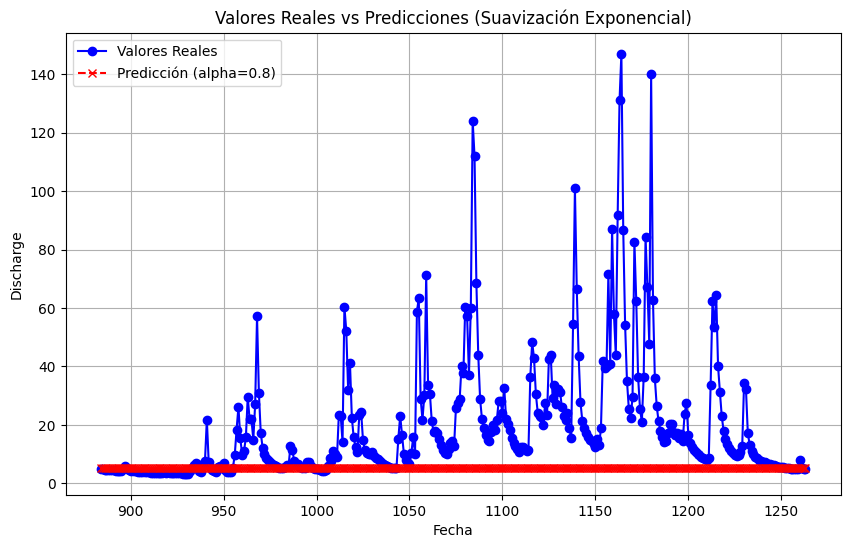

In [44]:
import matplotlib.pyplot as plt

def plot_real_vs_pred_optimized(train_data, test_data, best_alpha):
    # Crear el modelo con el mejor alpha encontrado
    ses_model = SimpleExpSmoothing(train_data).fit(smoothing_level=best_alpha, optimized=False)
    
    # Realizar predicciones
    y_pred = ses_model.forecast(len(test_data))
    
    # Graficar los valores reales y las predicciones
    plt.figure(figsize=(10, 6))
    plt.plot(test_data.index, test_data, label='Valores Reales', color='blue', marker='o', linestyle='-')
    plt.plot(test_data.index, y_pred, label=f'Predicción (alpha={best_alpha})', color='red', linestyle='--', marker='x')
    plt.xlabel('Fecha')
    plt.ylabel('Discharge')
    plt.title('Valores Reales vs Predicciones (Suavización Exponencial)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Usar la función para graficar con el alpha que has encontrado
plot_real_vs_pred_optimized(train_data['discharge_armley'], test_data['discharge_armley'], best_alpha)



Se puede observar que la gráfica de las predicciones no se asemeja. Esto es porque la serie tiene componentes de tendencia, estacionalidad e irregularidades. Por lo tanto usar SES NO es la mejor opción ya que este modelo no tiene encuenta la tendencia ni la estacionalidad

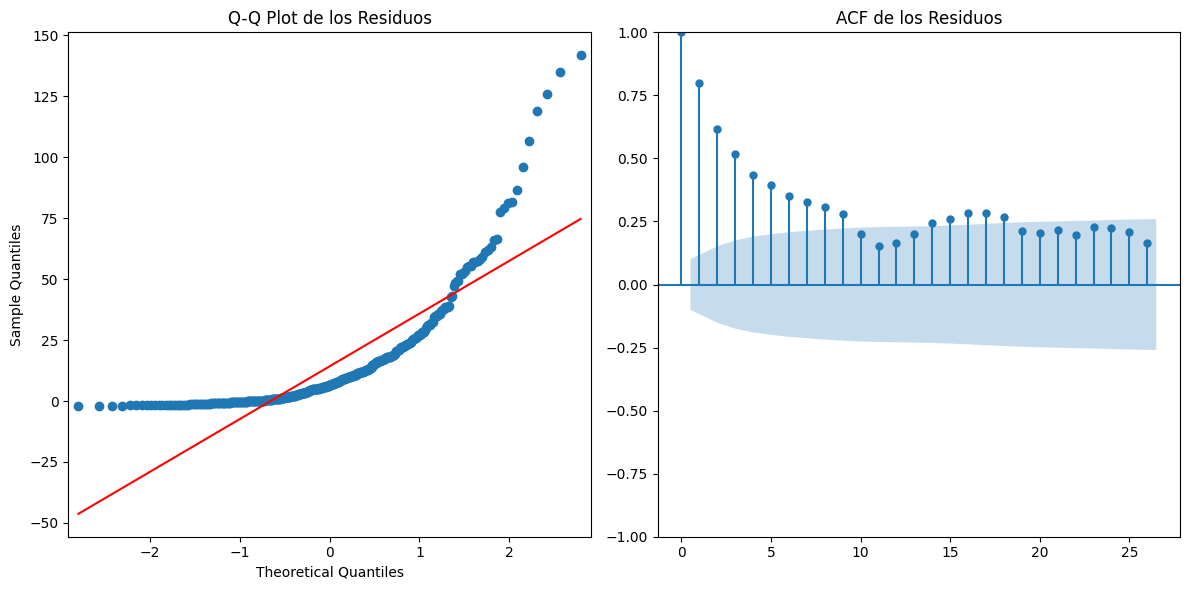

In [45]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import numpy as np

# Alpha ya definido
alpha = 0.5  # Usa el mejor valor de alpha obtenido previamente
train_series = train_data['discharge_armley']
test_series_length = len(test_data)  # Longitud del conjunto de prueba

# Ajustar el modelo de SES en los datos de entrenamiento
ses_model = SimpleExpSmoothing(train_series).fit(smoothing_level=alpha, optimized=False)

# Realizar las predicciones solo para el conjunto de prueba
y_pred = ses_model.forecast(steps=test_series_length)

# Cálculo de los residuos usando los valores de prueba reales y predichos
best_residuals = test_data['discharge_armley'] - y_pred  

# Graficar el Q-Q Plot y ACF de los residuos
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
qqplot(best_residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot de los Residuos')

plt.subplot(1, 2, 2)
plot_acf(best_residuals, ax=plt.gca())
plt.title('ACF de los Residuos')

plt.tight_layout()
plt.show()




En gráfico de Q-Q plot, la idea es que los puntos deberian alinearse a la diagonal roja si los residuos siguen una distribución normal. Es decir, los residuos no son completamente normales.

la ACF muestra que la correlación de los residuos en diferentes lags, además se observa que algunos lags tienen autocorrelación en los residuos


### Holt winters

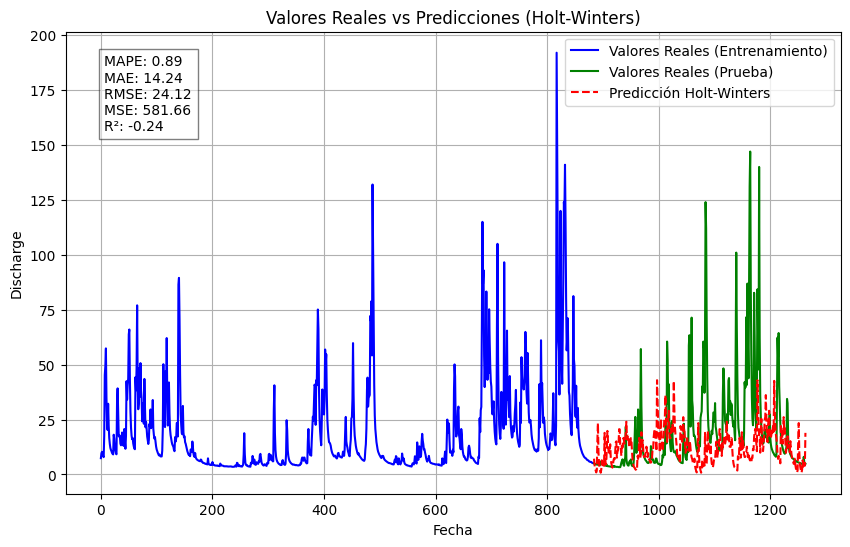

In [46]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Configuración del modelo Holt-Winters con tendencia y estacionalidad (si aplica)
train_series = train_data['discharge_armley']
test_series_length = len(test_data)

# Ajustar el modelo Holt-Winters sobre los datos de entrenamiento
holt_winters_model = ExponentialSmoothing(
    train_series, 
    trend=None,        # 'add' o 'mul' para tendencia
    seasonal='add',     # 'add' o 'mul' si hay estacionalidad
    seasonal_periods=180 # Ajustar según la periodicidad de tu serie
).fit()

# Predecir los valores de prueba
y_pred = holt_winters_model.forecast(steps=test_series_length)

# Calcular métricas de error
mape = mean_absolute_percentage_error(test_data['discharge_armley'], y_pred)
mae = mean_absolute_error(test_data['discharge_armley'], y_pred)
rmse = np.sqrt(mean_squared_error(test_data['discharge_armley'], y_pred))
mse = mean_squared_error(test_data['discharge_armley'], y_pred)
r2 = r2_score(test_data['discharge_armley'], y_pred)

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(train_series.index, train_series, label="Valores Reales (Entrenamiento)", color='blue')
plt.plot(test_data.index, test_data['discharge_armley'], label="Valores Reales (Prueba)", color='green')
plt.plot(test_data.index, y_pred, label="Predicción Holt-Winters", linestyle='--', color='red')

# Mostrar las métricas en el gráfico
error_text = f"MAPE: {mape:.2f}\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMSE: {mse:.2f}\nR²: {r2:.2f}"
plt.text(0.05, 0.95, error_text, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Discharge")
plt.title("Valores Reales vs Predicciones (Holt-Winters)")
plt.grid(True)
plt.show()



La predicción del modelo Holt Winters sigue un comportamiento descendiente de los datos reales hasta el final de la serie. El modelo captura razonablemente la tendencia baja, pero no muestra la misma magnitud de variabilidad

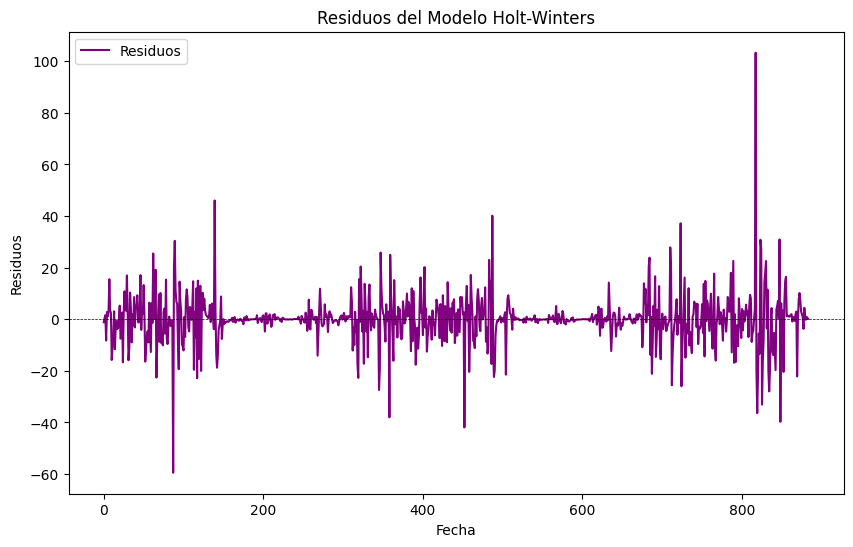

count    884.000000
mean      -0.031749
std        9.475199
min      -59.487557
25%       -2.555509
50%        0.011058
75%        2.762901
max      103.321047
dtype: float64


In [47]:
holt_winters_model = ExponentialSmoothing(
    train_series,
    trend='add',
    seasonal='add',
    seasonal_periods=365
).fit()

fitted_values = holt_winters_model.fittedvalues
residuals = train_series - fitted_values

plt.figure(figsize=(10, 6))
plt.plot(residuals, color='purple', label='Residuos')
plt.axhline(0, linestyle='--', color='black', linewidth=0.5)
plt.xlabel("Fecha")
plt.ylabel("Residuos")
plt.title("Residuos del Modelo Holt-Winters")
plt.legend()
plt.show()


print(residuals.describe())


Los residuos suelen oscilar en la línea cero, es decir que el modelo no presenta un sesgo evidente. La variabilidad de los residuos no parece ser consante a lo largo del tiempo.

### SARIMA

Mejor combinación de parámetros: SARIMA(1, 1, 1)x(1, 1, 0, 180) - AIC: 4315.709498968872


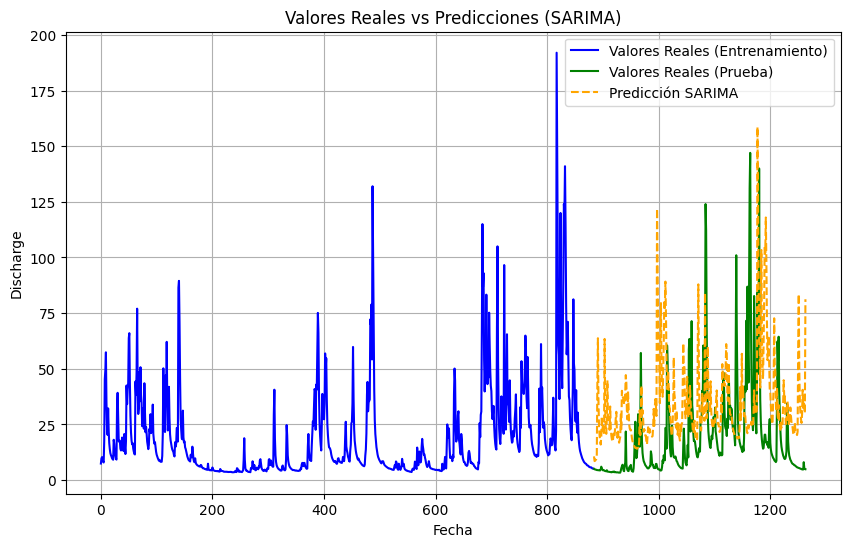

                                      SARIMAX Results                                       
Dep. Variable:                     discharge_armley   No. Observations:                  884
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 180)   Log Likelihood               -2869.533
Date:                              Sun, 27 Oct 2024   AIC                           5747.067
Time:                                      00:42:11   BIC                           5765.288
Sample:                                           0   HQIC                          5754.109
                                              - 884                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8210      0.023     36.428      0.000       0.777       0.865
ma.L1         -0.98

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Configuración de los datos
train_series = train_data['discharge_armley']
test_series = test_data['discharge_armley']

# Rangos de parámetros para la búsqueda en rejilla
p = d = q = range(0, 2)  # Rangos para (p, d, q)
P = D = Q = range(0, 2)  # Rangos para (P, D, Q)
seasonal_periods = [180]  # Períodos estacionales

# Combinaciones posibles para (p, d, q) y (P, D, Q, s)
pdq = [(x, y, z) for x in p for y in d for z in q]
seasonal_pdq = [(x, y, z, s) for x in P for y in D for z in Q for s in seasonal_periods]

# Variables para almacenar los mejores parámetros y error
best_pdq = None
best_seasonal_pdq = None
lowest_aic = float("inf")

# Búsqueda en rejilla de los mejores parámetros
for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            # Ajuste del modelo SARIMA
            sarima_model = SARIMAX(train_series, 
                                   order=param, 
                                   seasonal_order=seasonal_param,
                                   enforce_stationarity=False,
                                   enforce_invertibility=False).fit()
            # Comparar el criterio AIC para seleccionar el mejor modelo
            if sarima_model.aic < lowest_aic:
                lowest_aic = sarima_model.aic
                best_pdq = param
                best_seasonal_pdq = seasonal_param
        except Exception as e:
            continue

print(f"Mejor combinación de parámetros: SARIMA{best_pdq}x{best_seasonal_pdq} - AIC: {lowest_aic}")

# Entrenar modelo SARIMA con los mejores parámetros
best_sarima_model = SARIMAX(train_series, 
                            order=best_pdq, 
                            seasonal_order=best_seasonal_pdq).fit()

# Predicción sobre el conjunto de prueba
sarima_pred = best_sarima_model.predict(start=len(train_series), 
                                        end=len(train_series) + len(test_series) - 1)

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(train_series.index, train_series, label="Valores Reales (Entrenamiento)", color='blue')
plt.plot(test_data.index, test_series, label="Valores Reales (Prueba)", color='green')
plt.plot(test_data.index, sarima_pred, label="Predicción SARIMA", linestyle='--', color='orange')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Discharge")
plt.title("Valores Reales vs Predicciones (SARIMA)")
plt.grid(True)
plt.show()

# Resumen del modelo SARIMA
print(best_sarima_model.summary())




### Validaciones

In [49]:
from statsmodels.tsa.stattools import adfuller

def stationarity(ts, max_diff=3):
    d = 0
    adf_result = adfuller(ts, autolag='AIC')
    
    while adf_result[1] > 0.05 and d < max_diff:
        d += 1
        ts = ts.diff().dropna()  # Aplicar diferenciación
        adf_result = adfuller(ts, autolag='AIC')
        print(f"Diferenciación aplicada: d={d}, p-value={adf_result[1]}")
    
    if adf_result[1] > 0.05:
        print("Los datos no serán estacionarios incluso después de aplicar diferenciaciones.")
    else:
        print("Los datos son estacionarios.")
    
    return d, ts
d, diff_train_data = stationarity(train_data)
d, diff_test_data = stationarity(test_data)
d, diff_val_data = stationarity(val_data)
print(f"Número de diferenciaciones aplicadas: {d}")

TypeError: float() argument must be a string or a number, not 'Timestamp'

Los datos de caudal, no son estacionarios

In [54]:
#calculo de los errores
def errors(y_pred, y_real):
    
    mae = mean_absolute_error(y_real, y_pred)
    mape = 100*(sum(abs(((y_real - y_pred)/y_real)))/len(y_real))
    mse = mean_squared_error(y_real , y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    
    return mae, mape, mse, rmse, r2



In [18]:
#evaluacion de supuestos
def assumptions(residuals):

    warning = ""
    a = 0
    l = 10
    
    if len(residuals) < 10:
        l = 4
    #Independency
    #H0: The residuals are independent.
    #H1: The residuals aren't independent.    
    ljung_box_test = acorr_ljungbox(residuals, lags=l, return_df=True)
    ljung_box_pvalue = ljung_box_test['lb_pvalue'].values[0]
    
    if ljung_box_pvalue < 0.05:
        warning= warning + " The residuals aren't independent"
        a=a+1

    #Normality test
    #H0: The residuals have a normal distribution.
    #H1: The residuals don't have a normal distribution.
    jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(residuals)

    if jb_pvalue < 0.05:
        a = a+1
        warning = warning + " The residuals do not follow a normal distribution"

    return jb_pvalue, ljung_box_pvalue

In [19]:
#graficos supuestos
def plot_residuals(residuals):
    plt.figure(figsize=(12, 12))

    #Serie de residuos
    plt.subplot(3, 1, 1)
    plt.plot(residuals, label='Residuos', color='blue')
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Serie de Residuos')
    plt.xlabel('Índice')
    plt.ylabel('Residuo')
    plt.legend()

    #QQ Plot
    plt.subplot(3, 1, 2)
    sm.qqplot(residuals, line='s', ax=plt.gca())
    plt.title('QQ Plot de Residuos')

    #ACF de residuos
    plt.subplot(3, 1, 3)
    plot_acf(residuals, ax=plt.gca())
    plt.title('ACF de Residuos')

    plt.subplots_adjust(hspace=0.4)
    plt.tight_layout()
    plt.show()